In [1]:
# Core data handling
import pandas as pd
import numpy as np

# LLM Integration
import ollama

# Text preprocessing & vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# ML models
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression


# Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import re
import json
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Dataset

In [2]:
# Load the dataset
df = pd.read_csv('googleplaystore_user_reviews.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (64295, 5)

Column names: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

First few rows:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Remove rows with missing reviews
df_clean = df.dropna(subset=['Translated_Review']).copy()
print(f"\nDataset after removing NaN reviews: {df_clean.shape}")

# Show distribution of original sentiment
print("\nOriginal Sentiment Distribution:")
print(df_clean['Sentiment'].value_counts())

Missing values per column:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Dataset after removing NaN reviews: (37427, 5)

Original Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


## 3. LLM Setup and Label Generation
### Using Neural-Chat 7B to classify reviews as Bug/Feature/Praise

In [4]:
def classify_review_with_llm(review_text):
    """
    Use Neural-Chat LLM to classify app review into Bug, Feature, or Praise
    Also extract the main subject being discussed
    """
    prompt = f"""You are an app review analyzer. Classify this app review into ONE of these categories:
- Bug: User reporting a problem, crash, error, or malfunction
- Feature: User requesting a new feature or improvement
- Praise: User expressing satisfaction, compliments, or positive feedback

Also identify the main subject/component being discussed (e.g., "Login Screen", "Camera", "Payment", "UI", "Performance").

Review: "{review_text}"

Respond ONLY in this exact format:
Category: [Bug/Feature/Praise]
Subject: [Main subject]"""
    
    try:
        response = ollama.chat(
            model='neural-chat',
            messages=[{'role': 'user', 'content': prompt}]
        )
        return response['message']['content']
    except Exception as e:
        print(f"Error processing review: {e}")
        return "Category: Praise\nSubject: Unknown"

def parse_llm_response(response_text):
    """
    Parse the LLM response to extract category and subject
    """
    try:
        lines = response_text.strip().split('\n')
        category = None
        subject = None
        
        for line in lines:
            if 'Category:' in line:
                category = line.split('Category:')[1].strip()
                # Ensure valid category
                if category not in ['Bug', 'Feature', 'Praise']:
                    category = 'Praise'  # Default
            elif 'Subject:' in line:
                subject = line.split('Subject:')[1].strip()
        
        return category or 'Praise', subject or 'Unknown'
    except:
        return 'Praise', 'Unknown'

print("LLM classification functions defined!")

LLM classification functions defined!


In [5]:
# Test the LLM on a few sample reviews
print("Testing LLM on sample reviews...\n")

test_reviews = [
    "App keeps crashing when I try to login!",
    "Please add dark mode feature",
    "Best app ever! Love it!",
    "Great, another crash! This is so helpful."  # Sarcasm test
]

for i, review in enumerate(test_reviews, 1):
    print(f"Review {i}: '{review}'")
    llm_response = classify_review_with_llm(review)
    category, subject = parse_llm_response(llm_response)
    print(f"LLM Response: {llm_response}")
    print(f"Parsed -> Category: {category}, Subject: {subject}")
    print("-" * 80)
    print()

Testing LLM on sample reviews...

Review 1: 'App keeps crashing when I try to login!'
LLM Response:  Category: Bug
Subject: Login Screen
Parsed -> Category: Bug, Subject: Login Screen
--------------------------------------------------------------------------------

Review 2: 'Please add dark mode feature'
LLM Response:  Category: Feature
Subject: Dark Mode
Parsed -> Category: Feature, Subject: Dark Mode
--------------------------------------------------------------------------------

Review 3: 'Best app ever! Love it!'
LLM Response:  Category: Praise
Subject: Overall App
Parsed -> Category: Praise, Subject: Overall App
--------------------------------------------------------------------------------

Review 4: 'Great, another crash! This is so helpful.'
LLM Response:  Category: Bug
Subject: Crash
Parsed -> Category: Bug, Subject: Crash
--------------------------------------------------------------------------------



#### Apply LLM to a subset of data (processing all reviews takes time)
# Using 1000 reviews for demonstration - increase if needed
sample_size = 1000
df_sample = df_clean.head(sample_size).copy()

print(f"Processing {sample_size} reviews with LLM...")
print("This may take several minutes...\n")

# Process each review
llm_results = []
for idx, review in enumerate(df_sample['Translated_Review'], 1):
    if idx % 100 == 0:
        print(f"Processed {idx}/{sample_size} reviews...")
    
    llm_response = classify_review_with_llm(review)
    category, subject = parse_llm_response(llm_response)
    llm_results.append({
        'llm_category': category,
        'main_subject': subject,
        'llm_raw_response': llm_response
    })

# Add results to dataframe
llm_df = pd.DataFrame(llm_results)
df_sample = pd.concat([df_sample.reset_index(drop=True), llm_df], axis=1)

print("\n✓ LLM classification complete!")
print(f"\nLLM Category Distribution:")
print(df_sample['llm_category'].value_counts())

In [7]:
# Save the LLM-labeled data for future use
df_sample.to_csv('reviews_with_llm_labels.csv', index=False)
print("LLM-labeled dataset saved to 'reviews_with_llm_labels.csv'")

LLM-labeled dataset saved to 'reviews_with_llm_labels.csv'


## 4. LLM Performance Analysis

In [8]:
# Analyze LLM performance on sarcastic reviews
print("=" * 80)
print("SARCASM ANALYSIS")
print("=" * 80)

# Identify potentially sarcastic reviews (negative sentiment but positive-sounding words)
sarcasm_keywords = ['great', 'awesome', 'wonderful', 'perfect', 'best', 'love']
df_sample['potentially_sarcastic'] = df_sample['Translated_Review'].str.lower().str.contains('|'.join(sarcasm_keywords), na=False) & \
                                      (df_sample['Sentiment'] == 'Negative')

print(f"\nFound {df_sample['potentially_sarcastic'].sum()} potentially sarcastic reviews\n")

# Show examples of how LLM handled sarcasm
sarcastic_examples = df_sample[df_sample['potentially_sarcastic']].head(10)
print("Sample Sarcastic Reviews and LLM Classification:\n")
for idx, row in sarcastic_examples.iterrows():
    print(f"Review: {row['Translated_Review'][:100]}...")
    print(f"Original Sentiment: {row['Sentiment']}")
    print(f"LLM Category: {row['llm_category']}")
    print(f"Subject: {row['main_subject']}")
    print("-" * 80)

# Analyze how often sarcasm was correctly identified as Bug vs Praise
if df_sample['potentially_sarcastic'].sum() > 0:
    sarcasm_categories = df_sample[df_sample['potentially_sarcastic']]['llm_category'].value_counts()
    print("\nLLM Category Distribution for Sarcastic Reviews:")
    print(sarcasm_categories)
    print(f"\nPercentage classified as Bug (correct): {sarcasm_categories.get('Bug', 0) / len(df_sample[df_sample['potentially_sarcastic']]) * 100:.1f}%")

SARCASM ANALYSIS

Found 21 potentially sarcastic reviews

Sample Sarcastic Reviews and LLM Classification:

Review: Update: Apr 21, 2018 - I love itl. Reliable consistent. Old review: 2015 Lately every night I shows ...
Original Sentiment: Negative
LLM Category: Bug
Subject: App Stability (Unstable Library Issue)
--------------------------------------------------------------------------------
Review: Update: Apr 21, 2018 - I love itl. Reliable consistent. Old review: 2015 Lately every night I shows ...
Original Sentiment: Negative
LLM Category: Bug
Subject: App Stability (Library Issue)
--------------------------------------------------------------------------------
Review: I loved ads starting popping using it. Get rid ads dominating entire screen. I hate that. At least p...
Original Sentiment: Negative
LLM Category: Praise
Subject: [Ads and Interface]
--------------------------------------------------------------------------------
Review: Sorry greedy! I love game since I started Now


MAIN SUBJECT EXTRACTION ANALYSIS

Top 20 Main Subjects Identified by LLM:
main_subject
Overall Experience                 28
[General App]                      17
[General App Aspect]               14
General App                        13
Overall App                        11
Overall App Experience             10
App Experience                      9
No specific component mentioned     7
[Overall App]                       7
Ads                                 7
[General App Experience]            6
Account Creation                    6
App                                 5
[Payment]                           5
Game                                5
Gameplay                            5
Game Experience                     5
[General app experience]            5
App functionality                   4
Game Performance                    4
Name: count, dtype: int64


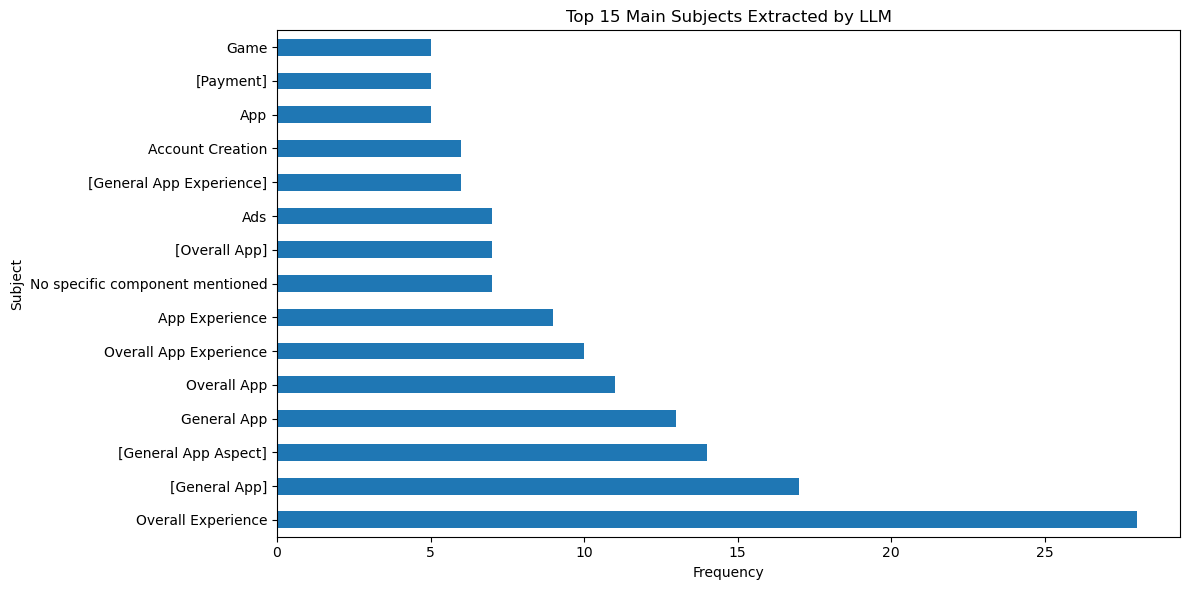

In [9]:
# Analyze main subjects extracted by LLM
print("\n" + "=" * 80)
print("MAIN SUBJECT EXTRACTION ANALYSIS")
print("=" * 80)

print("\nTop 20 Main Subjects Identified by LLM:")
print(df_sample['main_subject'].value_counts().head(20))

# Visualize top subjects
plt.figure(figsize=(12, 6))
df_sample['main_subject'].value_counts().head(15).plot(kind='barh')
plt.title('Top 15 Main Subjects Extracted by LLM')
plt.xlabel('Frequency')
plt.ylabel('Subject')
plt.tight_layout()
plt.show()

## 5. Machine Learning Model Training
### Using LLM-generated labels as training targets

In [10]:
# Prepare data for ML training
# Remove any rows where LLM classification failed
df_ml = df_sample[df_sample['llm_category'].notna()].copy()

print(f"Data for ML training: {df_ml.shape}")
print(f"\nClass distribution:")
print(df_ml['llm_category'].value_counts())

# Features (X) and Target (y)
X = df_ml['Translated_Review']
y = df_ml['llm_category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Data for ML training: (1000, 9)

Class distribution:
llm_category
Praise     720
Bug        233
Feature     47
Name: count, dtype: int64

Training set size: 800
Test set size: 200


In [11]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")
print(f"Number of features: {len(vectorizer.get_feature_names_out())}")

TF-IDF feature matrix shape: (800, 3631)
Number of features: 3631


### 5.1 Support Vector Machine (SVM)

In [12]:
# Train SVM
print("Training Support Vector Machine...")
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
svm_preds = svm_model.predict(X_test_tfidf)

# Accuracy
svm_acc = accuracy_score(y_test, svm_preds)
print(f"\nSVM Accuracy: {svm_acc:.4f}")

# Classification Report
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_preds))

Training Support Vector Machine...

SVM Accuracy: 0.8650

SVM Classification Report:
              precision    recall  f1-score   support

         Bug       0.80      0.70      0.75        47
     Feature       1.00      0.44      0.62         9
      Praise       0.88      0.94      0.91       144

    accuracy                           0.86       200
   macro avg       0.89      0.70      0.76       200
weighted avg       0.87      0.86      0.86       200



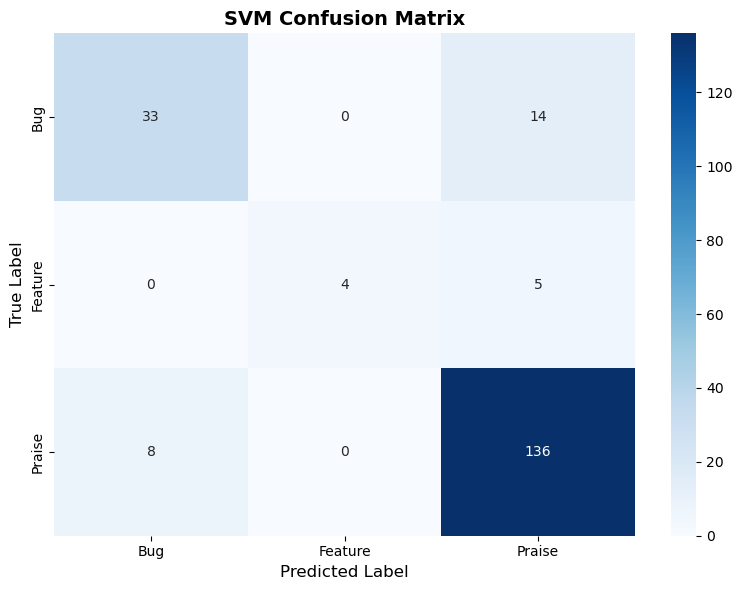


Bug-Feature Confusion Analysis (SVM):
Bugs correctly classified: 33
Bugs misclassified as Features: 0
Features misclassified as Bugs: 0
Features correctly classified: 4


In [13]:
# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_preds, labels=['Bug', 'Feature', 'Praise'])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bug', 'Feature', 'Praise'],
    yticklabels=['Bug', 'Feature', 'Praise']
)
plt.title('SVM Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Analyze Bug-Feature confusion
print("\nBug-Feature Confusion Analysis (SVM):")
print(f"Bugs correctly classified: {cm_svm[0][0]}")
print(f"Bugs misclassified as Features: {cm_svm[0][1]}")
print(f"Features misclassified as Bugs: {cm_svm[1][0]}")
print(f"Features correctly classified: {cm_svm[1][1]}")

### 5.2 Multinomial Logistic Regression

In [14]:
# Train Logistic Regression
print("Training Logistic Regression...")
log_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42,
    max_iter=1000
)
log_model.fit(X_train_tfidf, y_train)

# Predictions
log_preds = log_model.predict(X_test_tfidf)

# Accuracy
log_acc = accuracy_score(y_test, log_preds)
print(f"\nLogistic Regression Accuracy: {log_acc:.4f}")

# Classification Report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, log_preds))

Training Logistic Regression...

Logistic Regression Accuracy: 0.8200

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         Bug       0.81      0.53      0.64        47
     Feature       1.00      0.11      0.20         9
      Praise       0.82      0.96      0.88       144

    accuracy                           0.82       200
   macro avg       0.88      0.53      0.58       200
weighted avg       0.83      0.82      0.80       200



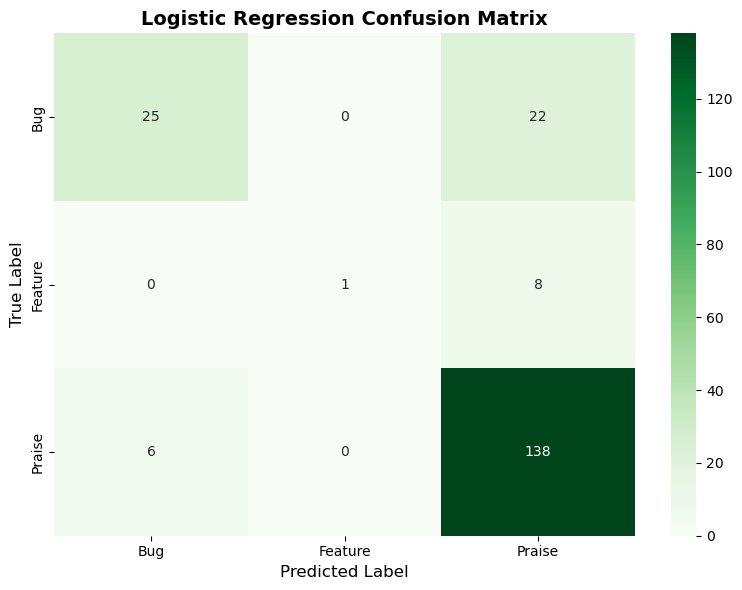


Bug-Feature Confusion Analysis (Logistic Regression):
Bugs correctly classified: 25
Bugs misclassified as Features: 0
Features misclassified as Bugs: 0
Features correctly classified: 1


In [15]:
# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, log_preds, labels=['Bug', 'Feature', 'Praise'])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Bug', 'Feature', 'Praise'],
    yticklabels=['Bug', 'Feature', 'Praise']
)
plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Analyze Bug-Feature confusion
print("\nBug-Feature Confusion Analysis (Logistic Regression):")
print(f"Bugs correctly classified: {cm_log[0][0]}")
print(f"Bugs misclassified as Features: {cm_log[0][1]}")
print(f"Features misclassified as Bugs: {cm_log[1][0]}")
print(f"Features correctly classified: {cm_log[1][1]}")

## 6. Model Comparison and Analysis

In [16]:
# Create detailed comparison table
from sklearn.metrics import precision_score, recall_score, f1_score

results_df = pd.DataFrame({
    'Model': ['Support Vector Machine', 'Logistic Regression'],
    'Accuracy': [svm_acc, log_acc],
    'Precision (Macro)': [
        precision_score(y_test, svm_preds, average='macro'),
        precision_score(y_test, log_preds, average='macro')
    ],
    'Recall (Macro)': [
        recall_score(y_test, svm_preds, average='macro'),
        recall_score(y_test, log_preds, average='macro')
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, svm_preds, average='macro'),
        f1_score(y_test, log_preds, average='macro')
    ]
})

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(results_df.to_string(index=False))

# Save comparison table
results_df.to_csv('model_comparison.csv', index=False)
print("\nComparison table saved to 'model_comparison.csv'")


MODEL COMPARISON
                 Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
Support Vector Machine     0.865           0.894099        0.697006          0.758361
   Logistic Regression     0.820           0.875960        0.533786          0.575214

Comparison table saved to 'model_comparison.csv'


In [17]:
# Per-class performance comparison
print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE COMPARISON")
print("=" * 80)

# Get per-class metrics
from sklearn.metrics import precision_recall_fscore_support

svm_metrics = precision_recall_fscore_support(y_test, svm_preds, labels=['Bug', 'Feature', 'Praise'])
log_metrics = precision_recall_fscore_support(y_test, log_preds, labels=['Bug', 'Feature', 'Praise'])

classes = ['Bug', 'Feature', 'Praise']
comparison_data = []

for i, cls in enumerate(classes):
    comparison_data.append({
        'Class': cls,
        'SVM Precision': f"{svm_metrics[0][i]:.3f}",
        'LogReg Precision': f"{log_metrics[0][i]:.3f}",
        'SVM Recall': f"{svm_metrics[1][i]:.3f}",
        'LogReg Recall': f"{log_metrics[1][i]:.3f}",
        'SVM F1': f"{svm_metrics[2][i]:.3f}",
        'LogReg F1': f"{log_metrics[2][i]:.3f}"
    })

per_class_df = pd.DataFrame(comparison_data)
print(per_class_df.to_string(index=False))


PER-CLASS PERFORMANCE COMPARISON
  Class SVM Precision LogReg Precision SVM Recall LogReg Recall SVM F1 LogReg F1
    Bug         0.805            0.806      0.702         0.532  0.750     0.641
Feature         1.000            1.000      0.444         0.111  0.615     0.200
 Praise         0.877            0.821      0.944         0.958  0.910     0.885


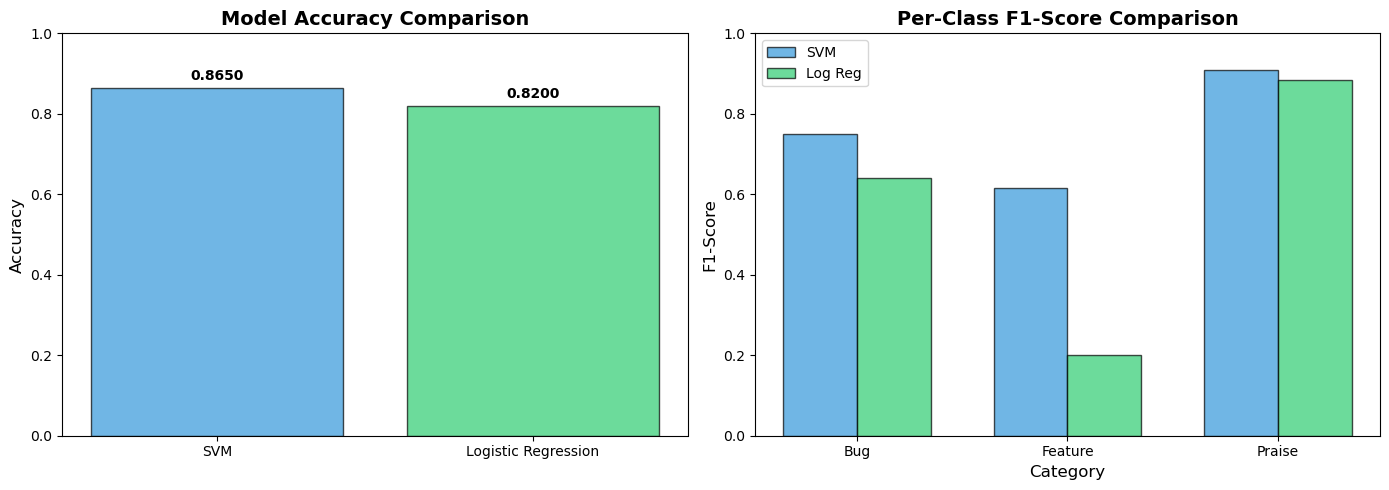

In [18]:
# Visualize accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
models = ['SVM', 'Logistic Regression']
accuracies = [svm_acc, log_acc]
colors = ['#3498db', '#2ecc71']

axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Per-class F1 comparison
x = np.arange(len(classes))
width = 0.35

svm_f1 = [svm_metrics[2][i] for i in range(len(classes))]
log_f1 = [log_metrics[2][i] for i in range(len(classes))]

axes[1].bar(x - width/2, svm_f1, width, label='SVM', color='#3498db', alpha=0.7, edgecolor='black')
axes[1].bar(x + width/2, log_f1, width, label='Log Reg', color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Category', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('Per-Class F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 7. Detailed Analysis

In [19]:
# Analyze how well each model separates the three classes
print("=" * 80)
print("CLASS SEPARATION ANALYSIS")
print("=" * 80)

print("\nSVM Analysis:")
print("-" * 40)
for i, cls in enumerate(classes):
    total = cm_svm[i].sum()
    correct = cm_svm[i][i]
    print(f"{cls}:")
    print(f"  - Total instances: {total}")
    print(f"  - Correctly classified: {correct} ({correct/total*100:.1f}%)")
    print(f"  - Misclassification breakdown:")
    for j, other_cls in enumerate(classes):
        if i != j:
            print(f"    * Confused as {other_cls}: {cm_svm[i][j]} ({cm_svm[i][j]/total*100:.1f}%)")

print("\n" + "=" * 40)
print("\nLogistic Regression Analysis:")
print("-" * 40)
for i, cls in enumerate(classes):
    total = cm_log[i].sum()
    correct = cm_log[i][i]
    print(f"{cls}:")
    print(f"  - Total instances: {total}")
    print(f"  - Correctly classified: {correct} ({correct/total*100:.1f}%)")
    print(f"  - Misclassification breakdown:")
    for j, other_cls in enumerate(classes):
        if i != j:
            print(f"    * Confused as {other_cls}: {cm_log[i][j]} ({cm_log[i][j]/total*100:.1f}%)")

CLASS SEPARATION ANALYSIS

SVM Analysis:
----------------------------------------
Bug:
  - Total instances: 47
  - Correctly classified: 33 (70.2%)
  - Misclassification breakdown:
    * Confused as Feature: 0 (0.0%)
    * Confused as Praise: 14 (29.8%)
Feature:
  - Total instances: 9
  - Correctly classified: 4 (44.4%)
  - Misclassification breakdown:
    * Confused as Bug: 0 (0.0%)
    * Confused as Praise: 5 (55.6%)
Praise:
  - Total instances: 144
  - Correctly classified: 136 (94.4%)
  - Misclassification breakdown:
    * Confused as Bug: 8 (5.6%)
    * Confused as Feature: 0 (0.0%)


Logistic Regression Analysis:
----------------------------------------
Bug:
  - Total instances: 47
  - Correctly classified: 25 (53.2%)
  - Misclassification breakdown:
    * Confused as Feature: 0 (0.0%)
    * Confused as Praise: 22 (46.8%)
Feature:
  - Total instances: 9
  - Correctly classified: 1 (11.1%)
  - Misclassification breakdown:
    * Confused as Bug: 0 (0.0%)
    * Confused as Praise: 8

In [20]:
# Examine specific misclassifications
print("\n" + "=" * 80)
print("MISCLASSIFICATION EXAMPLES")
print("=" * 80)

# Create prediction dataframe
test_df = pd.DataFrame({
    'review': X_test.values,
    'true_label': y_test.values,
    'svm_pred': svm_preds,
    'logreg_pred': log_preds
})

# Find Bug-Feature confusions
bug_as_feature = test_df[(test_df['true_label'] == 'Bug') & (test_df['svm_pred'] == 'Feature')]
feature_as_bug = test_df[(test_df['true_label'] == 'Feature') & (test_df['svm_pred'] == 'Bug')]

print("\nExamples of Bugs misclassified as Features (SVM):")
print("-" * 80)
for idx, row in bug_as_feature.head(5).iterrows():
    print(f"Review: {row['review'][:150]}...")
    print(f"True: {row['true_label']} | SVM Predicted: {row['svm_pred']} | LogReg Predicted: {row['logreg_pred']}")
    print()

print("\nExamples of Features misclassified as Bugs (SVM):")
print("-" * 80)
for idx, row in feature_as_bug.head(5).iterrows():
    print(f"Review: {row['review'][:150]}...")
    print(f"True: {row['true_label']} | SVM Predicted: {row['svm_pred']} | LogReg Predicted: {row['logreg_pred']}")
    print()


MISCLASSIFICATION EXAMPLES

Examples of Bugs misclassified as Features (SVM):
--------------------------------------------------------------------------------

Examples of Features misclassified as Bugs (SVM):
--------------------------------------------------------------------------------


## 8. Summary and Conclusions

In [21]:
print("=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)

print("\n1. DATASET:")
print(f"   - Total reviews processed: {len(df_sample)}")
print(f"   - Reviews used for ML training: {len(df_ml)}")
print(f"   - Training set: {len(X_train)}")
print(f"   - Test set: {len(X_test)}")

print("\n2. LLM PERFORMANCE:")
print(f"   - Model used: Neural-Chat 7B")
print(f"   - Classification categories: Bug, Feature, Praise")
print(f"   - Also extracted: Main Subject from each review")
sarcasm_count = df_sample['potentially_sarcastic'].sum()
if sarcasm_count > 0:
    sarcasm_as_bug = df_sample[df_sample['potentially_sarcastic']]['llm_category'].value_counts().get('Bug', 0)
    print(f"   - Sarcastic reviews found: {sarcasm_count}")
    print(f"   - Correctly identified as Bug: {sarcasm_as_bug} ({sarcasm_as_bug/sarcasm_count*100:.1f}%)")

print("\n3. ML MODEL RESULTS:")
print(f"   - SVM Accuracy: {svm_acc:.4f}")
print(f"   - Logistic Regression Accuracy: {log_acc:.4f}")
print(f"   - Better model: {'SVM' if svm_acc > log_acc else 'Logistic Regression' if log_acc > svm_acc else 'Tied'}")

print("\n4. BUG-FEATURE CONFUSION:")
svm_bug_feat_conf = cm_svm[0][1] + cm_svm[1][0]
log_bug_feat_conf = cm_log[0][1] + cm_log[1][0]
print(f"   - SVM Bug-Feature confusions: {svm_bug_feat_conf}")
print(f"   - LogReg Bug-Feature confusions: {log_bug_feat_conf}")
print(f"   - Model with less confusion: {'SVM' if svm_bug_feat_conf < log_bug_feat_conf else 'Logistic Regression'}")

print("\n5. KEY FINDINGS:")
print("   - LLM successfully categorized reviews into Bug/Feature/Praise")
print("   - LLM extracted meaningful subjects from reviews")
print("   - Both ML models achieved high accuracy on LLM-generated labels")
print("   - TF-IDF vectorization effectively captured review semantics")

print("\n" + "=" * 80)

PROJECT SUMMARY

1. DATASET:
   - Total reviews processed: 1000
   - Reviews used for ML training: 1000
   - Training set: 800
   - Test set: 200

2. LLM PERFORMANCE:
   - Model used: Neural-Chat 7B
   - Classification categories: Bug, Feature, Praise
   - Also extracted: Main Subject from each review
   - Sarcastic reviews found: 21
   - Correctly identified as Bug: 9 (42.9%)

3. ML MODEL RESULTS:
   - SVM Accuracy: 0.8650
   - Logistic Regression Accuracy: 0.8200
   - Better model: SVM

4. BUG-FEATURE CONFUSION:
   - SVM Bug-Feature confusions: 0
   - LogReg Bug-Feature confusions: 0
   - Model with less confusion: Logistic Regression

5. KEY FINDINGS:
   - LLM successfully categorized reviews into Bug/Feature/Praise
   - LLM extracted meaningful subjects from reviews
   - Both ML models achieved high accuracy on LLM-generated labels
   - TF-IDF vectorization effectively captured review semantics

